# SMI Portfolio Optimisation
## Markowitz Mean-Variance Framework with SARON as Risk-Free Rate

**Package:** [`swiss-finance-data`](https://github.com/EMen11/swiss-finance-data)

This notebook demonstrates a full Markowitz portfolio optimisation workflow using official Swiss financial data:

| Data | Source | API |
|------|--------|-----|
| SMI historical prices (20 constituents, 3Y) | Yahoo Finance via yfinance | `SMI.get_historical_prices()` |
| SARON daily fixing (CHF risk-free rate) | Swiss National Bank | `SNB.get_saron_daily()` |

### Workflow
1. Fetch 3 years of closing prices for all 20 SMI constituents
2. Compute daily returns and annualised statistics
3. Monte Carlo simulation — 10,000 random portfolios
4. Solve for **Maximum Sharpe Ratio** and **Minimum Variance** portfolios via `scipy.optimize`
5. Compute and plot the **Efficient Frontier**
6. Analyse portfolio composition

> **Requirements:** `pip install swiss-finance-data scipy seaborn`

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

from swiss_finance import SNB, SMI

sns.set_theme(style='whitegrid', font_scale=1.1)
print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Collection

In [2]:
# --- SMI Historical Prices (3 years) ---
print('Fetching SMI historical prices...')
prices = SMI.get_historical_prices(period='3y')

print(f'  {prices.shape[1]} constituents | {len(prices)} trading days')
print(f'  Period: {prices.index[0].date()} to {prices.index[-1].date()}')

# Daily log returns (more stable for optimisation)
returns = np.log(prices / prices.shift(1)).dropna()
print(f'  Daily log returns shape: {returns.shape}')
prices.tail(3)

Fetching SMI historical prices...
  20 constituents | 751 trading days
  Period: 2023-03-06 to 2026-03-06
  Daily log returns shape: (605, 20)


Ticker,ABBN.SW,ALC.SW,CFR.SW,GEBN.SW,GIVN.SW,HOLN.SW,LONN.SW,NESN.SW,NOVN.SW,PGHN.SW,ROG.SW,SCMN.SW,SDZ.SW,SIKA.SW,SLHN.SW,SREN.SW,STMN.SW,UBSG.SW,VACN.SW,ZURN.SW
Date,,,,,,,,,,,,,,,,,,,,
2026-03-04,67.959999,65.239998,145.550003,606.200012,2926.0,67.739998,525.599976,80.580002,127.680000,833.000000,358.799988,720.5,66.400002,151.699997,840.799988,129.850006,88.199997,30.99,537.400024,545.000000
2026-03-05,66.580002,64.379997,143.550003,590.599976,2900.0,67.199997,514.599976,80.139999,124.820000,832.599976,351.500000,714.5,64.660004,147.100006,838.000000,129.050003,84.879997,30.59,521.200012,535.200012
2026-03-06,65.440002,62.279999,141.600006,574.400024,2866.0,64.839996,505.600006,79.529999,122.900002,814.400024,340.100006,712.5,63.160000,141.800003,819.799988,126.900002,84.220001,29.68,506.000000,527.400024


In [3]:
# --- SARON Daily Fixing as CHF Risk-Free Rate ---
saron_daily = SNB.get_saron_daily()
rf_annual = saron_daily / 100      # SARON is quoted as annual %
rf_daily  = rf_annual / 252

print(f'SARON daily fixing : {saron_daily:.4f}%')
print(f'Risk-free rate     : {rf_annual:.4f} (annual) | {rf_daily:.6f} (daily)')

SARON daily fixing : -0.0800%
Risk-free rate     : -0.0008 (annual) | -0.000003 (daily)


---
## 2. Universe Analysis

In [4]:
# --- Annualised Statistics per Asset ---
constituents = SMI.get_constituents()
ann_returns = returns.mean() * 252
ann_vols    = returns.std()  * np.sqrt(252)
sharpe_ind  = (ann_returns - rf_annual) / ann_vols

stats = pd.DataFrame({
    'Company'         : [constituents.get(t, t) for t in ann_returns.index],
    'Ann. Return'     : ann_returns.values,
    'Ann. Volatility' : ann_vols.values,
    'Sharpe Ratio'    : sharpe_ind.values,
}, index=ann_returns.index).sort_values('Sharpe Ratio', ascending=False)

stats.style.format({
    'Ann. Return'     : '{:.1%}',
    'Ann. Volatility' : '{:.1%}',
    'Sharpe Ratio'    : '{:.2f}',
}).background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')

,Company,Ann. Return,Ann. Volatility,Sharpe Ratio
Ticker,,,,
ABBN.SW,ABB,30.6%,25.0%,1.23
SLHN.SW,Swiss Life,19.6%,17.2%,1.14
SCMN.SW,Swisscom,15.0%,14.4%,1.05
SDZ.SW,Sandoz,33.1%,32.6%,1.02
NOVN.SW,Novartis,17.3%,18.5%,0.94
ZURN.SW,Zurich Insurance,14.9%,16.5%,0.91
SREN.SW,Swiss Re,18.2%,22.4%,0.81
ROG.SW,Roche,16.5%,21.7%,0.76
UBSG.SW,UBS Group,15.3%,27.1%,0.57


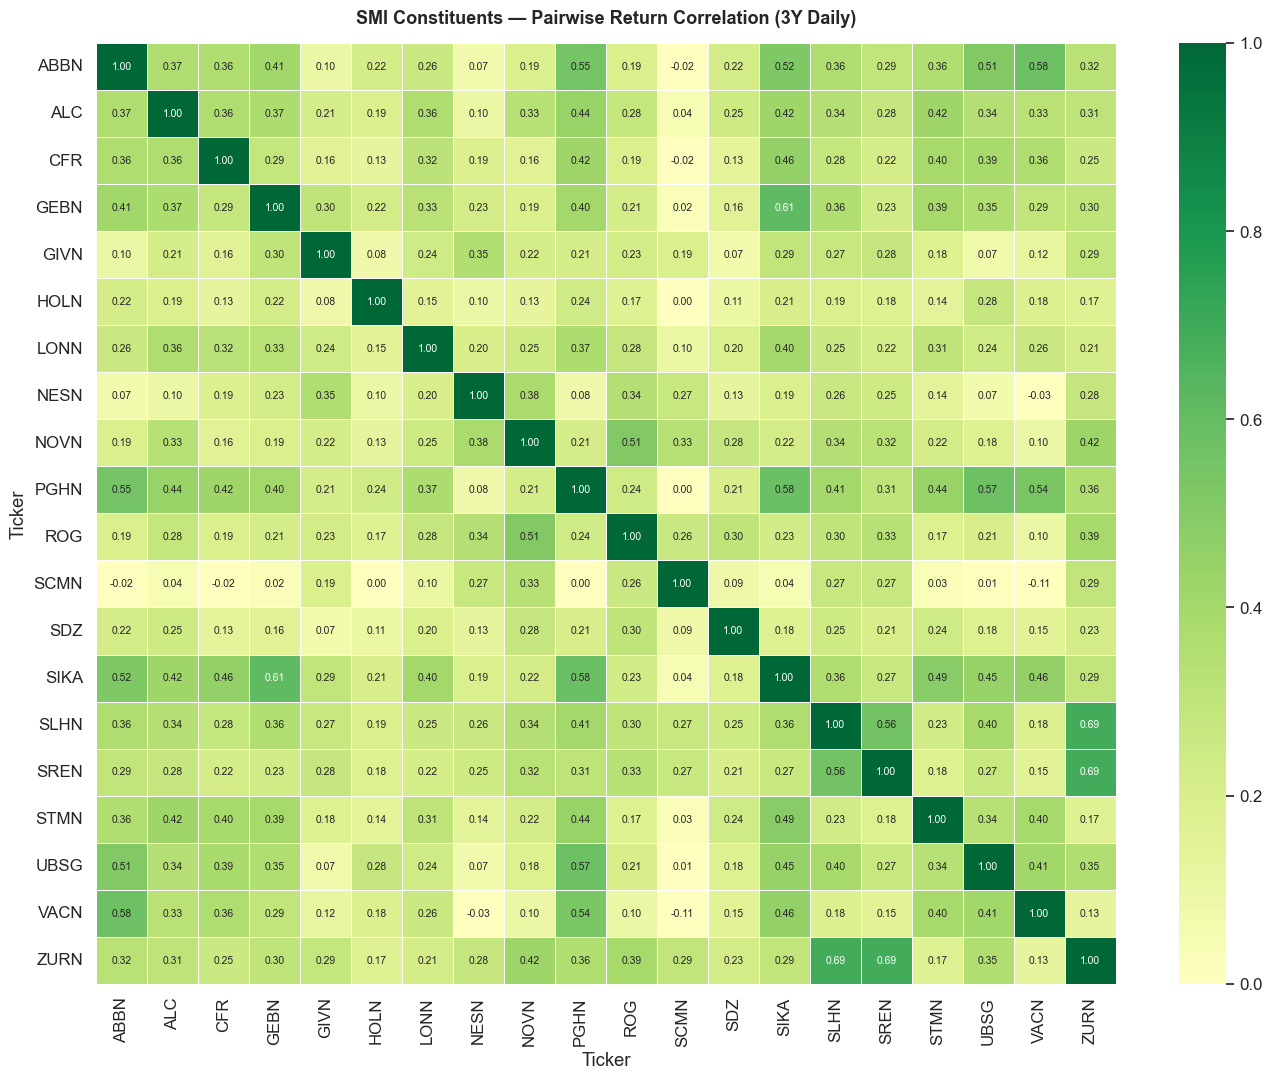

In [5]:
# --- Correlation Matrix ---
corr = returns.corr()
short = {t: t.replace('.SW', '') for t in corr.columns}
corr_plot = corr.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_plot,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=0, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 7.5}, ax=ax
)
ax.set_title(
    'SMI Constituents — Pairwise Return Correlation (3Y Daily)',
    fontsize=13, fontweight='bold', pad=14
)
plt.tight_layout()
plt.show()

---
## 3. Markowitz Optimisation Setup

In [6]:
# --- Inputs ---
mu  = ann_returns.values                    # expected annual returns (n,)
cov = returns.cov().values * 252            # annualised covariance matrix (n x n)
n   = len(mu)
w0  = np.ones(n) / n                        # equal-weight starting point

# Long-only, fully invested
bounds      = tuple((0.0, 1.0) for _ in range(n))
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

def portfolio_perf(w):
    """Return (annual_return, annual_vol, sharpe) for weight vector w."""
    ret    = w @ mu
    vol    = np.sqrt(w @ cov @ w)
    sharpe = (ret - rf_annual) / vol
    return ret, vol, sharpe

def neg_sharpe(w):
    ret, vol, _ = portfolio_perf(w)
    return -(ret - rf_annual) / vol

def portfolio_var(w):
    return w @ cov @ w

# Sanity check: equal-weight portfolio
ret_eq, vol_eq, sr_eq = portfolio_perf(w0)
print(f'Equal-weight baseline   ->  Return: {ret_eq:.2%}  |  Vol: {vol_eq:.2%}  |  Sharpe: {sr_eq:.3f}')

Equal-weight baseline   ->  Return: 9.69%  |  Vol: 14.08%  |  Sharpe: 0.694


---
## 4. Monte Carlo Simulation

In [7]:
N = 15_000
np.random.seed(42)

sim_rets    = np.empty(N)
sim_vols    = np.empty(N)
sim_sharpes = np.empty(N)

for i in range(N):
    w = np.random.dirichlet(np.ones(n))
    r, v, s = portfolio_perf(w)
    sim_rets[i]    = r
    sim_vols[i]    = v
    sim_sharpes[i] = s

print(f'{N:,} random portfolios simulated')
print(f'Return range  : [{sim_rets.min():.1%}, {sim_rets.max():.1%}]')
print(f'Volatility    : [{sim_vols.min():.1%}, {sim_vols.max():.1%}]')
print(f'Sharpe range  : [{sim_sharpes.min():.2f}, {sim_sharpes.max():.2f}]')

15,000 random portfolios simulated
Return range  : [-2.6%, 20.6%]
Volatility    : [11.2%, 25.4%]
Sharpe range  : [-0.15, 1.39]


---
## 5. Exact Optimisation

In [8]:
# --- Maximum Sharpe Ratio Portfolio ---
res_sharpe = minimize(
    neg_sharpe, w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-10}
)
assert res_sharpe.success, 'Max Sharpe optimisation failed'
w_sharpe = res_sharpe.x
ret_sharpe, vol_sharpe, sr_sharpe = portfolio_perf(w_sharpe)

print('Maximum Sharpe Ratio Portfolio')
print(f'  Return     : {ret_sharpe:.2%}')
print(f'  Volatility : {vol_sharpe:.2%}')
print(f'  Sharpe     : {sr_sharpe:.4f}')

Maximum Sharpe Ratio Portfolio
  Return     : 22.11%
  Volatility : 12.29%
  Sharpe     : 1.8048


In [9]:
# --- Minimum Variance Portfolio ---
res_minvar = minimize(
    portfolio_var, w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000, 'ftol': 1e-10}
)
assert res_minvar.success, 'Min Variance optimisation failed'
w_minvar = res_minvar.x
ret_minvar, vol_minvar, sr_minvar = portfolio_perf(w_minvar)

print('Minimum Variance Portfolio')
print(f'  Return     : {ret_minvar:.2%}')
print(f'  Volatility : {vol_minvar:.2%}')
print(f'  Sharpe     : {sr_minvar:.4f}')

Minimum Variance Portfolio
  Return     : 11.65%
  Volatility : 10.43%
  Sharpe     : 1.1243


---
## 6. Efficient Frontier

In [10]:
# Sweep target returns from min-variance to max achievable
ret_lo = ret_minvar
ret_hi = mu.max() * 0.98
targets = np.linspace(ret_lo, ret_hi, 80)

ef_vols = []
ef_rets = []

for target in targets:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: (w @ mu) - t}
    ]
    res = minimize(
        portfolio_var, w0,
        method='SLSQP',
        bounds=bounds,
        constraints=cons,
        options={'maxiter': 500, 'ftol': 1e-10}
    )
    if res.success:
        ef_vols.append(np.sqrt(res.fun))
        ef_rets.append(target)

print(f'Efficient frontier: {len(ef_rets)} points')

Efficient frontier: 80 points


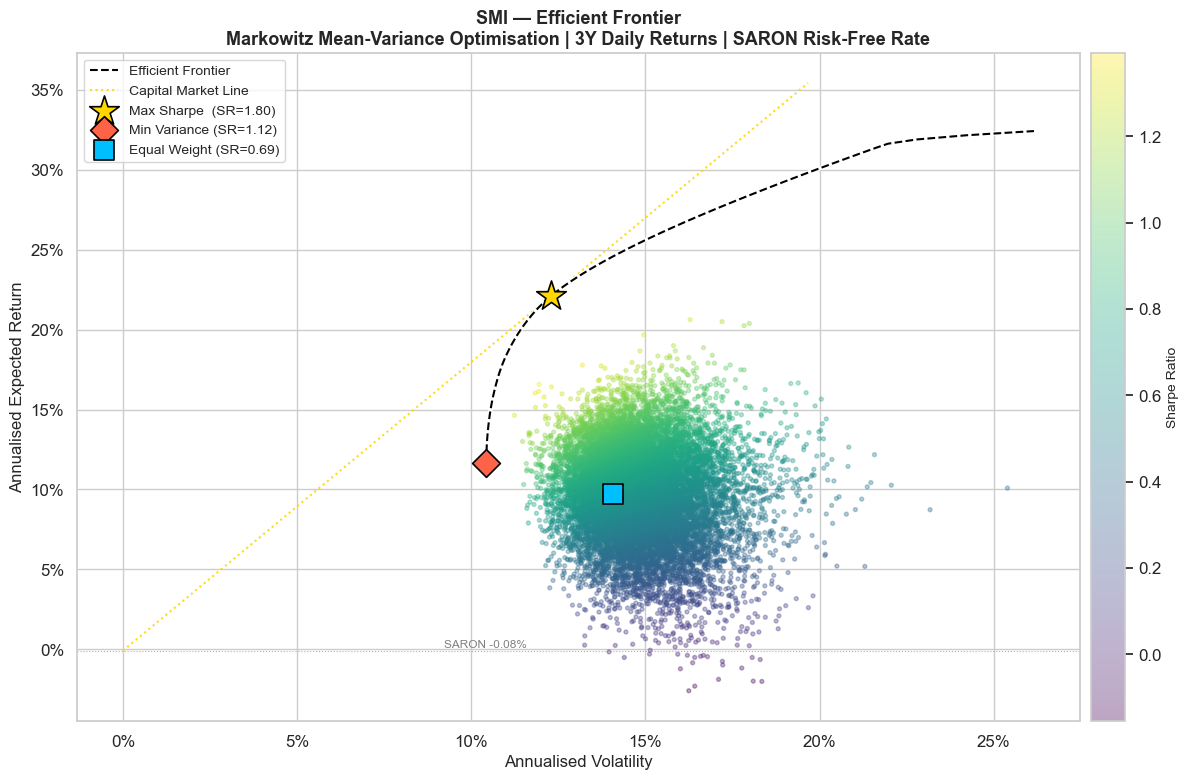

Figure saved: smi_efficient_frontier.png


In [11]:
fig, ax = plt.subplots(figsize=(13, 8))

# Monte Carlo cloud
sc = ax.scatter(
    sim_vols, sim_rets,
    c=sim_sharpes, cmap='viridis',
    alpha=0.35, s=8, zorder=1
)
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Sharpe Ratio', fontsize=10)

# Efficient frontier
ax.plot(ef_vols, ef_rets, 'white', lw=3,   zorder=3)
ax.plot(ef_vols, ef_rets, 'black', lw=1.5, zorder=4, linestyle='--', label='Efficient Frontier')

# Capital Market Line
x_cml = np.linspace(0, vol_sharpe * 1.6, 100)
y_cml = rf_annual + sr_sharpe * x_cml
ax.plot(x_cml, y_cml, color='gold', lw=1.5, linestyle=':', alpha=0.9, label='Capital Market Line')

# Special portfolios
ax.scatter(vol_sharpe, ret_sharpe,
           marker='*', s=500, color='gold', edgecolors='black', linewidth=1.2, zorder=5,
           label=f'Max Sharpe  (SR={sr_sharpe:.2f})')
ax.scatter(vol_minvar, ret_minvar,
           marker='D', s=200, color='tomato', edgecolors='black', linewidth=1.2, zorder=5,
           label=f'Min Variance (SR={sr_minvar:.2f})')
ax.scatter(vol_eq, ret_eq,
           marker='s', s=200, color='deepskyblue', edgecolors='black', linewidth=1.2, zorder=5,
           label=f'Equal Weight (SR={sr_eq:.2f})')

# Risk-free rate on y-axis
ax.axhline(rf_annual, color='grey', lw=0.8, linestyle=':', alpha=0.6)
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else sim_vols.min() * 0.82,
        rf_annual + 0.002, f'SARON {saron_daily:.2f}%', fontsize=8.5, color='grey')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('Annualised Volatility', fontsize=12)
ax.set_ylabel('Annualised Expected Return', fontsize=12)
ax.set_title(
    'SMI — Efficient Frontier\nMarkowitz Mean-Variance Optimisation | 3Y Daily Returns | SARON Risk-Free Rate',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('smi_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: smi_efficient_frontier.png')

---
## 7. Portfolio Composition

In [12]:
def weights_table(weights, label):
    df = pd.DataFrame({
        'Company' : [constituents.get(t, t) for t in returns.columns],
        'Weight'  : weights
    }, index=returns.columns)
    df = df[df['Weight'] > 0.005].sort_values('Weight', ascending=False)
    df['Weight'] = df['Weight'].map('{:.1%}'.format)
    print(f'\n{label}  ({(weights > 0.005).sum()} positions)')
    print(df.to_string())

weights_table(w_sharpe, 'Maximum Sharpe Ratio Portfolio')
weights_table(w_minvar, 'Minimum Variance Portfolio')


Maximum Sharpe Ratio Portfolio  (5 positions)
            Company Weight
Ticker                    
SCMN.SW    Swisscom  40.6%
ABBN.SW         ABB  26.0%
SLHN.SW  Swiss Life  14.2%
SDZ.SW       Sandoz  12.3%
NOVN.SW    Novartis   7.0%

Minimum Variance Portfolio  (13 positions)
                  Company Weight
Ticker                          
SCMN.SW          Swisscom  41.2%
NESN.SW            Nestle  12.0%
ZURN.SW  Zurich Insurance   8.6%
GEBN.SW           Geberit   7.2%
GIVN.SW          Givaudan   7.2%
ABBN.SW               ABB   4.8%
ALC.SW              Alcon   3.8%
NOVN.SW          Novartis   3.6%
SLHN.SW        Swiss Life   2.6%
UBSG.SW         UBS Group   2.5%
VACN.SW         VAT Group   2.3%
SDZ.SW             Sandoz   2.1%
CFR.SW          Richemont   1.8%


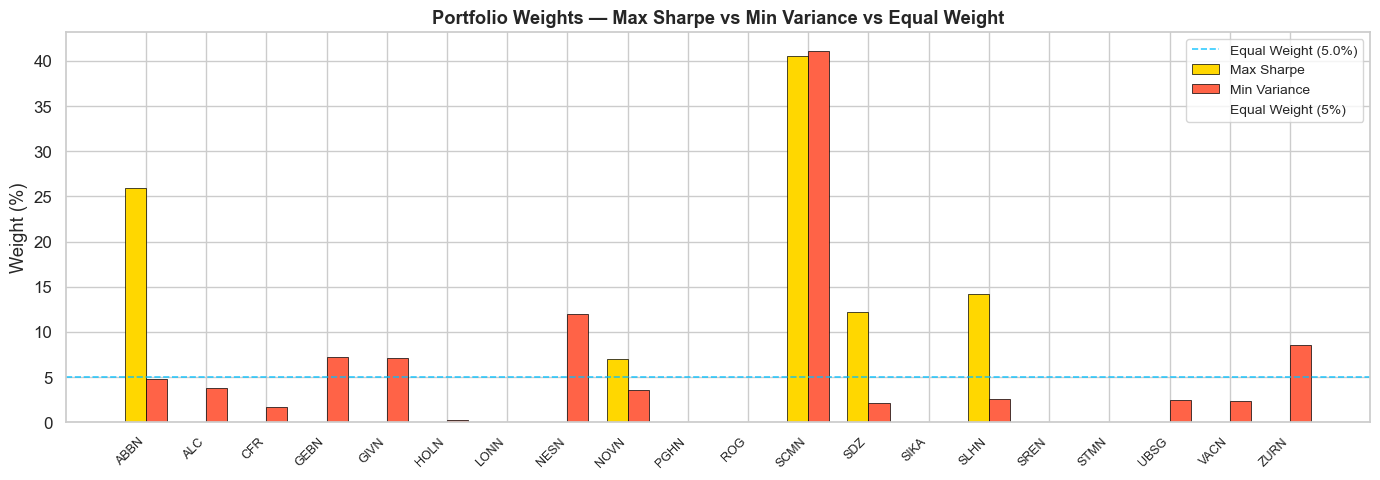

In [13]:
# --- Side-by-side bar chart of portfolio weights ---
tickers_short = [t.replace('.SW', '') for t in returns.columns]

x = np.arange(n)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, w_sharpe * 100, width, label='Max Sharpe',    color='gold',     edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, w_minvar * 100, width, label='Min Variance',  color='tomato',   edgecolor='black', linewidth=0.5)
ax.bar(x,           np.ones(n) * 5, 0,     label='Equal Weight (5%)', color='deepskyblue', alpha=0)
ax.axhline(100/n, color='deepskyblue', lw=1.2, linestyle='--', alpha=0.8, label=f'Equal Weight ({100/n:.1f}%)')

ax.set_xticks(x)
ax.set_xticklabels(tickers_short, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Weight (%)')
ax.set_title('Portfolio Weights — Max Sharpe vs Min Variance vs Equal Weight', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Summary

In [14]:
summary = pd.DataFrame([
    {
        'Portfolio'       : 'Maximum Sharpe Ratio',
        'Ann. Return'     : ret_sharpe,
        'Ann. Volatility' : vol_sharpe,
        'Sharpe Ratio'    : sr_sharpe,
        'Positions'       : int((w_sharpe > 0.005).sum())
    },
    {
        'Portfolio'       : 'Minimum Variance',
        'Ann. Return'     : ret_minvar,
        'Ann. Volatility' : vol_minvar,
        'Sharpe Ratio'    : sr_minvar,
        'Positions'       : int((w_minvar > 0.005).sum())
    },
    {
        'Portfolio'       : 'Equal Weight',
        'Ann. Return'     : ret_eq,
        'Ann. Volatility' : vol_eq,
        'Sharpe Ratio'    : sr_eq,
        'Positions'       : 20
    },
]).set_index('Portfolio')

summary.style.format({
    'Ann. Return'     : '{:.2%}',
    'Ann. Volatility' : '{:.2%}',
    'Sharpe Ratio'    : '{:.3f}',
}).background_gradient(subset=['Sharpe Ratio'], cmap='RdYlGn')

,Ann. Return,Ann. Volatility,Sharpe Ratio,Positions
Portfolio,,,,
Maximum Sharpe Ratio,22.11%,12.29%,1.805,5
Minimum Variance,11.65%,10.43%,1.124,13
Equal Weight,9.69%,14.08%,0.694,20


---
## Conclusion

This notebook demonstrated how `swiss-finance-data` enables a full quantitative workflow:

- **Two API calls** (`SMI.get_historical_prices()`, `SNB.get_saron_daily()`) provide everything needed
- The **SARON** replaces LIBOR CHF as the standard risk-free rate for CHF-denominated portfolios
- The **Efficient Frontier** shows the risk/return trade-off achievable within the SMI universe
- The **Maximum Sharpe portfolio** concentrates on the best risk-adjusted names
- The **Minimum Variance portfolio** provides the lowest-risk fully-invested allocation

### Extensions
- Add a **maximum weight constraint** (e.g., `bounds = (0.0, 0.15)`) to enforce diversification
- Use **CPI inflation data** (`CPI.get_inflation_yoy()`) to compute real returns
- Extend the universe with **CHF bonds** once `swiss-finance-data v0.5.0` is released
- Run a **rolling optimisation** to analyse how the optimal portfolio evolves over time